In [1]:
import warnings
from hmmlearn.hmm import GaussianHMM
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge

# Configure institutional visualization settings
sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.1)
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

C:\Users\ippol\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. DATA INGESTION

In [ ]:
file_path_imputed = "Dataset3_PortfolioReplicaStrategyErrataCorrige.xlsx"
file_path_metadata = "Dataset3_PortfolioReplicaStrategy.xlsx"

# Extract full asset names (row 4) and Bloomberg tickers (row 6)
full_names_df = pd.read_excel(
    file_path_metadata, header=None, skiprows=3, nrows=1
)
full_names = full_names_df.iloc[0].tolist()[1:]

tickers_df = pd.read_excel(file_path_metadata, header=None, skiprows=5, nrows=1)
tickers = tickers_df.iloc[0].tolist()[1:]
variable_info = dict(zip(tickers, full_names))

# Ingest historical price series
data_raw = pd.read_excel(file_path_imputed, header=None, skiprows=1)
data_raw.columns = ["Date"] + tickers
data_raw["Date"] = pd.to_datetime(data_raw["Date"], format="%d/%m/%Y")
prices_df = data_raw.set_index("Date").sort_index()

print("--- DATA INGESTION SUMMARY ---")
print(f"Dataset Dimensions: {prices_df.shape[0]} observations, {prices_df.shape[1]} assets.")
print(
    f"Chronological Span: {prices_df.index.min().date()} to"
    f" {prices_df.index.max().date()}\n"
)

--- DATA INGESTION SUMMARY ---
Dataset Dimensions: 705 observations, 15 assets.
Chronological Span: 2007-10-23 to 2021-04-20



# 2. TARGET BENCHMARK CONSTRUCTION

In [3]:
# Compute discrete simple weekly returns: R_t = (P_t / P_{t-1}) - 1
returns_df = prices_df.pct_change().dropna()

# Construct multi-asset target benchmark (Y_t)
index_weights = {
    "HFRXGL Index": 0.50,  # Hedge Fund Research Global Index - 50%
    "MXWO Index": 0.25,  # MSCI World Equity Index - 25%
    "LEGATRUU Index": 0.25,  # Bloomberg Global Aggregate Bond Index - 25%
}

target_returns = pd.Series(0.0, index=returns_df.index, name="Target_Index")
for ticker, weight in index_weights.items():
    target_returns += returns_df[ticker] * weight

# Define active replication futures universe (C_t)
futures_universe = [
    "RX1 Comdty",
    "TY1 Comdty",
    "GC1 Comdty",
    "CO1 Comdty",
    "ES1 Comdty",
    "VG1 Comdty",
    "NQ1 Comdty",
    "LLL1 Comdty",
    "TP1 Comdty",
    "DU1 Comdty",
    "TU2 Comdty",
]

# Rigorous alignment between Target Index (Y) and Replication Universe (C)
common_dates = target_returns.index.intersection(returns_df.index)
Y_series = target_returns.loc[common_dates]
C_matrix = returns_df.loc[common_dates, futures_universe]

# 3. DATASET PARTITION (60% / 20% / 20%)

In [4]:
T_total = len(Y_series)
idx_60 = int(T_total * 0.60)
idx_80 = int(T_total * 0.80)

# A. Estimation Set (0% - 60%): Used for HMM fitting and Ridge prior initialization
Y_estimation = Y_series.iloc[:idx_60]
C_estimation = C_matrix.iloc[:idx_60]

# B. Pseudo-Out-of-Sample (POOS) Validation Set (60% - 80%): Used for Optuna hyperparameter search
Y_poos_val = Y_series.iloc[idx_60:idx_80]
C_poos_val = C_matrix.iloc[idx_60:idx_80]

# C. Combined In-Sample Development Set (0% - 80%): Used to fit the static OLS Baseline
Y_combined_insample = Y_series.iloc[:idx_80]
C_combined_insample = C_matrix.iloc[:idx_80]

# D. Pure Holdout Test Set (80% - 100%): True Out-of-Sample live-simulation evaluation
Y_holdout_test = Y_series.iloc[idx_80:]
C_holdout_test = C_matrix.iloc[idx_80:]

print("--- UNAMBIGUOUS CHRONOLOGICAL PARTITIONING PROTOCOL ---")
print(
    f"1. Estimation Set      (0%-60%):  {len(Y_estimation)} weeks |"
    f" {Y_estimation.index.min().date()} -> {Y_estimation.index.max().date()}"
)
print(
    f"2. POOS Validation Set (60%-80%): {len(Y_poos_val)} weeks  |"
    f" {Y_poos_val.index.min().date()} -> {Y_poos_val.index.max().date()}"
)
print(
    f"--> Combined In-Sample (0%-80%):  {len(Y_combined_insample)} weeks |"
    f" {Y_combined_insample.index.min().date()} ->"
    f" {Y_combined_insample.index.max().date()} (OLS Fit Window)"
)
print(
    f"3. Holdout Test Set    (80%-100%):{len(Y_holdout_test)} weeks  |"
    f" {Y_holdout_test.index.min().date()} ->"
    f" {Y_holdout_test.index.max().date()}\n"
)

--- UNAMBIGUOUS CHRONOLOGICAL PARTITIONING PROTOCOL ---
1. Estimation Set      (0%-60%):  422 weeks | 2007-10-30 -> 2015-11-24
2. POOS Validation Set (60%-80%): 141 weeks  | 2015-12-01 -> 2018-08-07
--> Combined In-Sample (0%-80%):  563 weeks | 2007-10-30 -> 2018-08-07 (OLS Fit Window)
3. Holdout Test Set    (80%-100%):141 weeks  | 2018-08-14 -> 2021-04-20



# 4. STATIC OLS BASELINE


In [5]:
# Fit regression without intercept to force pure linear replication across assets
model_ols = LinearRegression(fit_intercept=False).fit(
    C_combined_insample.values, Y_combined_insample.values
)

ols_weights = pd.Series(
    model_ols.coef_, index=futures_universe, name="OLS_Weight"
)
ols_gross_exposure = ols_weights.abs().sum()

# Project OLS replication returns across In-Sample and Holdout Test partitions
ols_ret_insample = pd.Series(
    model_ols.predict(C_combined_insample.values),
    index=C_combined_insample.index,
)
ols_ret_test = pd.Series(
    model_ols.predict(C_holdout_test.values), index=C_holdout_test.index
)
ols_ret_full = pd.concat([ols_ret_insample, ols_ret_test])

print("--- STATIC OLS BASELINE WEIGHTS (TRAINED ON 0%-80% COMBINED BLOCK) ---")
print(ols_weights.round(4).to_string())
print(f"Static Portfolio Gross Exposure: {ols_gross_exposure:.4f}\n")


--- STATIC OLS BASELINE WEIGHTS (TRAINED ON 0%-80% COMBINED BLOCK) ---
RX1 Comdty     0.0485
TY1 Comdty     0.1770
GC1 Comdty     0.0323
CO1 Comdty     0.0180
ES1 Comdty     0.1448
VG1 Comdty     0.0575
NQ1 Comdty     0.0102
LLL1 Comdty    0.0400
TP1 Comdty     0.0503
DU1 Comdty    -0.4446
TU2 Comdty     0.1270
Static Portfolio Gross Exposure: 1.1502



# 5. CAUSAL HMM REGIME DETECTION


In [6]:
# Fit 3-state Gaussian HMM strictly on Estimation Set to prevent look-ahead bias
hmm_model = GaussianHMM(
    n_components=3, covariance_type="full", n_iter=1000, random_state=42
)
hmm_model.fit(Y_estimation.values.reshape(-1, 1))


def predict_causal_regimes(model, series):
    """Computes forward-only regime probabilities (alpha filtering)

    to prevent Viterbi full-sample smoothing look-ahead bias.
    """
    X = series.values.reshape(-1, 1)
    T_obs = len(X)
    log_frameprob = model._compute_log_likelihood(X)
    log_startprob = np.log(model.startprob_ + 1e-10)
    log_transmat = np.log(model.transmat_ + 1e-10)

    causal_states = np.zeros(T_obs, dtype=int)
    work_buffer = log_startprob + log_frameprob[0]
    causal_states[0] = np.argmax(work_buffer)

    for t in range(1, T_obs):
        max_log = np.max(work_buffer)
        alpha_prev = np.exp(work_buffer - max_log)
        trans_prob = np.dot(alpha_prev, model.transmat_)
        work_buffer = np.log(trans_prob + 1e-10) + max_log + log_frameprob[t]
        causal_states[t] = np.argmax(work_buffer)

    return causal_states


# Compute regimes and variance on Training set (0% -> 60%)
train_states = predict_causal_regimes(hmm_model, Y_estimation)
train_variances = Y_estimation.groupby(train_states).var().sort_values()

# Build mapping dictionary (pi) using only past knowledge
immutable_reg_map = {old_id: new_id for new_id, old_id in enumerate(train_variances.index)}

# Project raw regimes onto the entire dataset and translate using the frozen map
raw_regimes_full = predict_causal_regimes(hmm_model, Y_series)
regime_series = pd.Series(raw_regimes_full, index=Y_series.index).map(immutable_reg_map).astype(int)

# 6. REGIME-SWITCHING KALMAN PORTFOLIO REPLICATOR


In [7]:
class InstitutionalKalmanReplicator:
    """State-space portfolio replicator with HMM-conditioned noise covariances."""

    def __init__(self, Q_std_map, R_std_map, transaction_cost=0.0005):
        self.Q_std_map = Q_std_map
        self.R_std_map = R_std_map
        self.transaction_cost = transaction_cost

    def fit(self, Y_vals, C_vals, regimes, ridge_alpha=1.0):
        T_obs, N_assets = C_vals.shape
        self.x_predicted = np.zeros((T_obs, N_assets))
        self.x_filtered = np.zeros((T_obs, N_assets))
        self.y_hat_exante = np.zeros(T_obs)

        # Initialize prior state vector via Ridge regression on first quarter (12 weeks)
        ridge_init = Ridge(alpha=ridge_alpha, fit_intercept=False).fit(
            C_vals[:12], Y_vals[:12]
        )
        x_prev = ridge_init.coef_
        P_prev = np.eye(N_assets) * 0.01

        for t in range(T_obs):
            reg = int(regimes[t])
            Q_mat = np.eye(N_assets) * (self.Q_std_map.get(reg, 0.01) ** 2)
            R_val = self.R_std_map.get(reg, 0.01) ** 2

            C_t = C_vals[t].reshape(1, -1)
            y_t = Y_vals[t]

            # 1. EX-ANTE PREDICTION STEP (A Priori State and Covariance)
            x_pred = x_prev
            P_pred = P_prev + Q_mat
            y_hat_t = (C_t @ x_pred).item()

            # 2. BAYESIAN UPDATE STEP (Kalman Gain & Posterior State)
            S_val = (C_t @ P_pred @ C_t.T).item() + R_val
            K_gain = (P_pred @ C_t.T) / S_val

            innovation = y_t - y_hat_t
            x_new = x_pred + K_gain.flatten() * innovation

            # Joseph form covariance update for numerical stability
            I_KC = np.eye(N_assets) - K_gain @ C_t
            P_new = I_KC @ P_pred @ I_KC.T + (K_gain @ K_gain.T) * R_val

            # 3. TURNOVER AND TRANSACTION COST ACCOUNTING
            if t > 0:
                turnover = np.sum(np.abs(x_pred - self.x_predicted[t - 1]))
                tc = self.transaction_cost * turnover
            else:
                tc = 0.0

            self.y_hat_exante[t] = y_hat_t - tc
            self.x_filtered[t] = x_new
            self.x_predicted[t] = x_pred
            x_prev, P_prev = x_new, P_new

        return self

    def get_exante_weights(self):
        return self.x_predicted

    def predict_returns(self):
        return self.y_hat_exante

# 7. OPTUNA META-OPTIMIZATION

In [8]:
print(
    "Running Optuna hyperparameter optimization strictly on POOS Validation Set"
    " (60%-80%)..."
)


def objective(trial):
    Q_candidates = {
        0: trial.suggest_float("Q_std_0", 1e-4, 0.05, log=True),
        1: trial.suggest_float("Q_std_1", 1e-4, 0.10, log=True),
        2: trial.suggest_float("Q_std_2", 1e-3, 0.20, log=True),
    }
    R_candidates = {
        0: trial.suggest_float("R_std_0", 1e-4, 0.05, log=True),
        1: trial.suggest_float("R_std_1", 1e-4, 0.10, log=True),
        2: trial.suggest_float("R_std_2", 1e-3, 0.20, log=True),
    }

    # Fit model across Combined In-Sample Block (0% -> 80%)
    model_cv = InstitutionalKalmanReplicator(
        Q_std_map=Q_candidates, R_std_map=R_candidates
    )
    model_cv.fit(
        Y_combined_insample.values,
        C_combined_insample.values,
        regime_series.iloc[:idx_80].values,
    )

    # Evaluate loss exclusively on the POOS Validation window (60% -> 80%)
    val_preds = model_cv.predict_returns()[idx_60:idx_80]
    val_true = Y_poos_val.values

    val_tracking_error = np.std(val_preds - val_true) * np.sqrt(52)
    return val_tracking_error


study = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=150)

best_Q = {
    reg: study.best_params[f"Q_std_{reg}"] for reg in range(3)
}
best_R = {
    reg: study.best_params[f"R_std_{reg}"] for reg in range(3)
}
print(
    "Optimization complete. Optimal POOS Validation Tracking Error:"
    f" {study.best_value*100:.2f}%"
)
print(
    f"Optimal Process Noise Std (Q): {[f'{best_Q[r]:.5f}' for r in range(3)]}"
)
print(
    f"Optimal Observation Noise Std (R): {[f'{best_R[r]:.5f}' for r in range(3)]}\n"
)


Running Optuna hyperparameter optimization strictly on POOS Validation Set (60%-80%)...
Optimization complete. Optimal POOS Validation Tracking Error: 2.05%
Optimal Process Noise Std (Q): ['0.00203', '0.00480', '0.08188']
Optimal Observation Noise Std (R): ['0.00714', '0.00642', '0.00167']



# 8. EXECUTION & GENERATION OF DYNAMIC REPLICATION SERIES

In [9]:
kalman_model = InstitutionalKalmanReplicator(
    Q_std_map=best_Q, R_std_map=best_R, transaction_cost=0.0005
)
kalman_model.fit(Y_series.values, C_matrix.values, regime_series.values)

kalman_weights_df = pd.DataFrame(
    kalman_model.get_exante_weights(),
    index=Y_series.index,
    columns=futures_universe,
)
kalman_ret_full = pd.Series(
    kalman_model.predict_returns(), index=Y_series.index, name="Kalman_Return"
)

# Slice series across In-Sample (0%-80%) and Holdout Test (80%-100%) partitions
kalman_ret_insample = kalman_ret_full.iloc[:idx_80]
kalman_ret_test = kalman_ret_full.iloc[idx_80:]


# 9. RESULTS

In [10]:
def compute_institutional_metrics(
    r_target, r_model, weights_sub=None, is_benchmark=False, freq=52
):
    """Computes a standardized 8-metric institutional evaluation vector with exact geometric CAGR."""
    T_periods = len(r_model)
    cum_r = (1.0 + r_model).cumprod()
    
    # Corrected Exact Geometric CAGR
    ann_ret = (cum_r.iloc[-1] / 1.0) ** (freq / T_periods) - 1.0
    
    ann_vol = r_model.std(ddof=1) * np.sqrt(freq)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else 0.0
    max_dd = (1.0 - cum_r / cum_r.cummax()).max()

    if is_benchmark:
        te_str, ir_str, corr_str, gross_str = "-", "-", "1.0000", "1.00"
    else:
        diff = r_model - r_target
        te = diff.std(ddof=1) * np.sqrt(freq)
        ir = (diff.mean() * freq) / te if te != 0 else 0.0
        corr = np.corrcoef(r_model, r_target)[0, 1]

        if weights_sub is None:
            gross_exp = 1.0
        elif isinstance(weights_sub, (int, float)):
            gross_exp = float(weights_sub)
        elif isinstance(weights_sub, pd.Series):
            gross_exp = weights_sub.abs().sum()
        else:
            gross_exp = weights_sub.abs().sum(axis=1).mean()

        te_str = f"{te*100:.2f}%"
        ir_str = f"{ir:+.2f}"
        corr_str = f"{corr:.4f}"
        gross_str = f"{gross_exp:.2f}"

    return [
        f"{ann_ret*100:.2f}%",
        f"{ann_vol*100:.2f}%",
        f"{sharpe:.2f}",
        f"{max_dd*100:.2f}%",
        te_str,
        ir_str,
        corr_str,
        gross_str,
    ]


metric_labels = [
    "Annualized Return (CAGR)",
    "Annualized Volatility",
    "Sharpe Ratio (Rf=0)",
    "Maximum Drawdown",
    "Tracking Error (vs Target)",
    "Information Ratio",
    "Correlation with Target",
    "Avg Gross Exposure",
]

# Assemble Master Comparison Dictionary (Grouped by Architectural Partition)
master_performance_data = {
    (
        "1. Combined In-Sample Block (0%-80%)",
        "Target Benchmark",
    ): compute_institutional_metrics(
        Y_combined_insample, Y_combined_insample, is_benchmark=True
    ),
    (
        "1. Combined In-Sample Block (0%-80%)",
        "Static OLS Baseline",
    ): compute_institutional_metrics(
        Y_combined_insample, ols_ret_insample, weights_sub=ols_weights
    ),
    (
        "1. Combined In-Sample Block (0%-80%)",
        "Kalman Replicator",
    ): compute_institutional_metrics(
        Y_combined_insample,
        kalman_ret_insample,
        weights_sub=kalman_weights_df.iloc[:idx_80],
    ),
    (
        "2. Pure Holdout Test Set (80%-100%)",
        "Target Benchmark",
    ): compute_institutional_metrics(
        Y_holdout_test, Y_holdout_test, is_benchmark=True
    ),
    (
        "2. Pure Holdout Test Set (80%-100%)",
        "Static OLS Baseline",
    ): compute_institutional_metrics(
        Y_holdout_test, ols_ret_test, weights_sub=ols_weights
    ),
    (
        "2. Pure Holdout Test Set (80%-100%)",
        "Kalman Replicator",
    ): compute_institutional_metrics(
        Y_holdout_test,
        kalman_ret_test,
        weights_sub=kalman_weights_df.iloc[idx_80:],
    ),
}

df_master_table = pd.DataFrame(master_performance_data, index=metric_labels)

print(
    "=" * 105
)
print(
    "            MASTER INSTITUTIONAL PERFORMANCE MATRIX (OLS FIT ON COMBINED"
    " IN-SAMPLE BLOCK)            "
)
print(
    "=" * 105
)
display(df_master_table)

            MASTER INSTITUTIONAL PERFORMANCE MATRIX (OLS FIT ON COMBINED IN-SAMPLE BLOCK)            


1. Combined In-Sample Block (0%-80%)  \
                                               Target Benchmark   
Annualized Return (CAGR)                                  1.37%   
Annualized Volatility                                     6.11%   
Sharpe Ratio (Rf=0)                                        0.22   
Maximum Drawdown                                         29.01%   
Tracking Error (vs Target)                                    -   
Information Ratio                                             -   
Correlation with Target                                  1.0000   
Avg Gross Exposure                                         1.00   

                                                                  \
                           Static OLS Baseline Kalman Replicator   
Annualized Return (CAGR)                 1.53%             0.73%   
Annualized Volatility                    5.51%             5.50%   
Sharpe Ratio (Rf=0)                       0.28              0.13   
Maximum Drawdown                        20.82%            23.28%   
Tracking Error (vs Target)               2.65%             3.05%   
Information Ratio                        +0.04             -0.22   
Correlation with Target                 0.9008            0.8670   
Avg Gross Exposure                        1.15              0.59   

                           2. Pure Holdout Test Set (80%-100%)  \
                                              Target Benchmark   
Annualized Return (CAGR)                                 6.57%   
Annualized Volatility                                    7.12%   
Sharpe Ratio (Rf=0)                                       0.92   
Maximum Drawdown                                        13.39%   
Tracking Error (vs Target)                                   -   
Information Ratio                                            -   
Correlation with Target                                 1.0000   
Avg Gross Exposure                                        1.00   

                                                                  
                           Static OLS Baseline Kalman Replicator  
Annualized Return (CAGR)                 5.01%             5.95%  
Annualized Volatility                    5.75%             6.13%  
Sharpe Ratio (Rf=0)                       0.87              0.97  
Maximum Drawdown                         9.56%             8.68%  
Tracking Error (vs Target)               3.46%             3.76%  
Information Ratio                        -0.45             -0.17  
Correlation with Target                 0.8762            0.8490  
Avg Gross Exposure                        1.15              0.67

# 10. CONSOLIDATED 4-PANEL MASTER INSTITUTIONAL VISUALIZATION

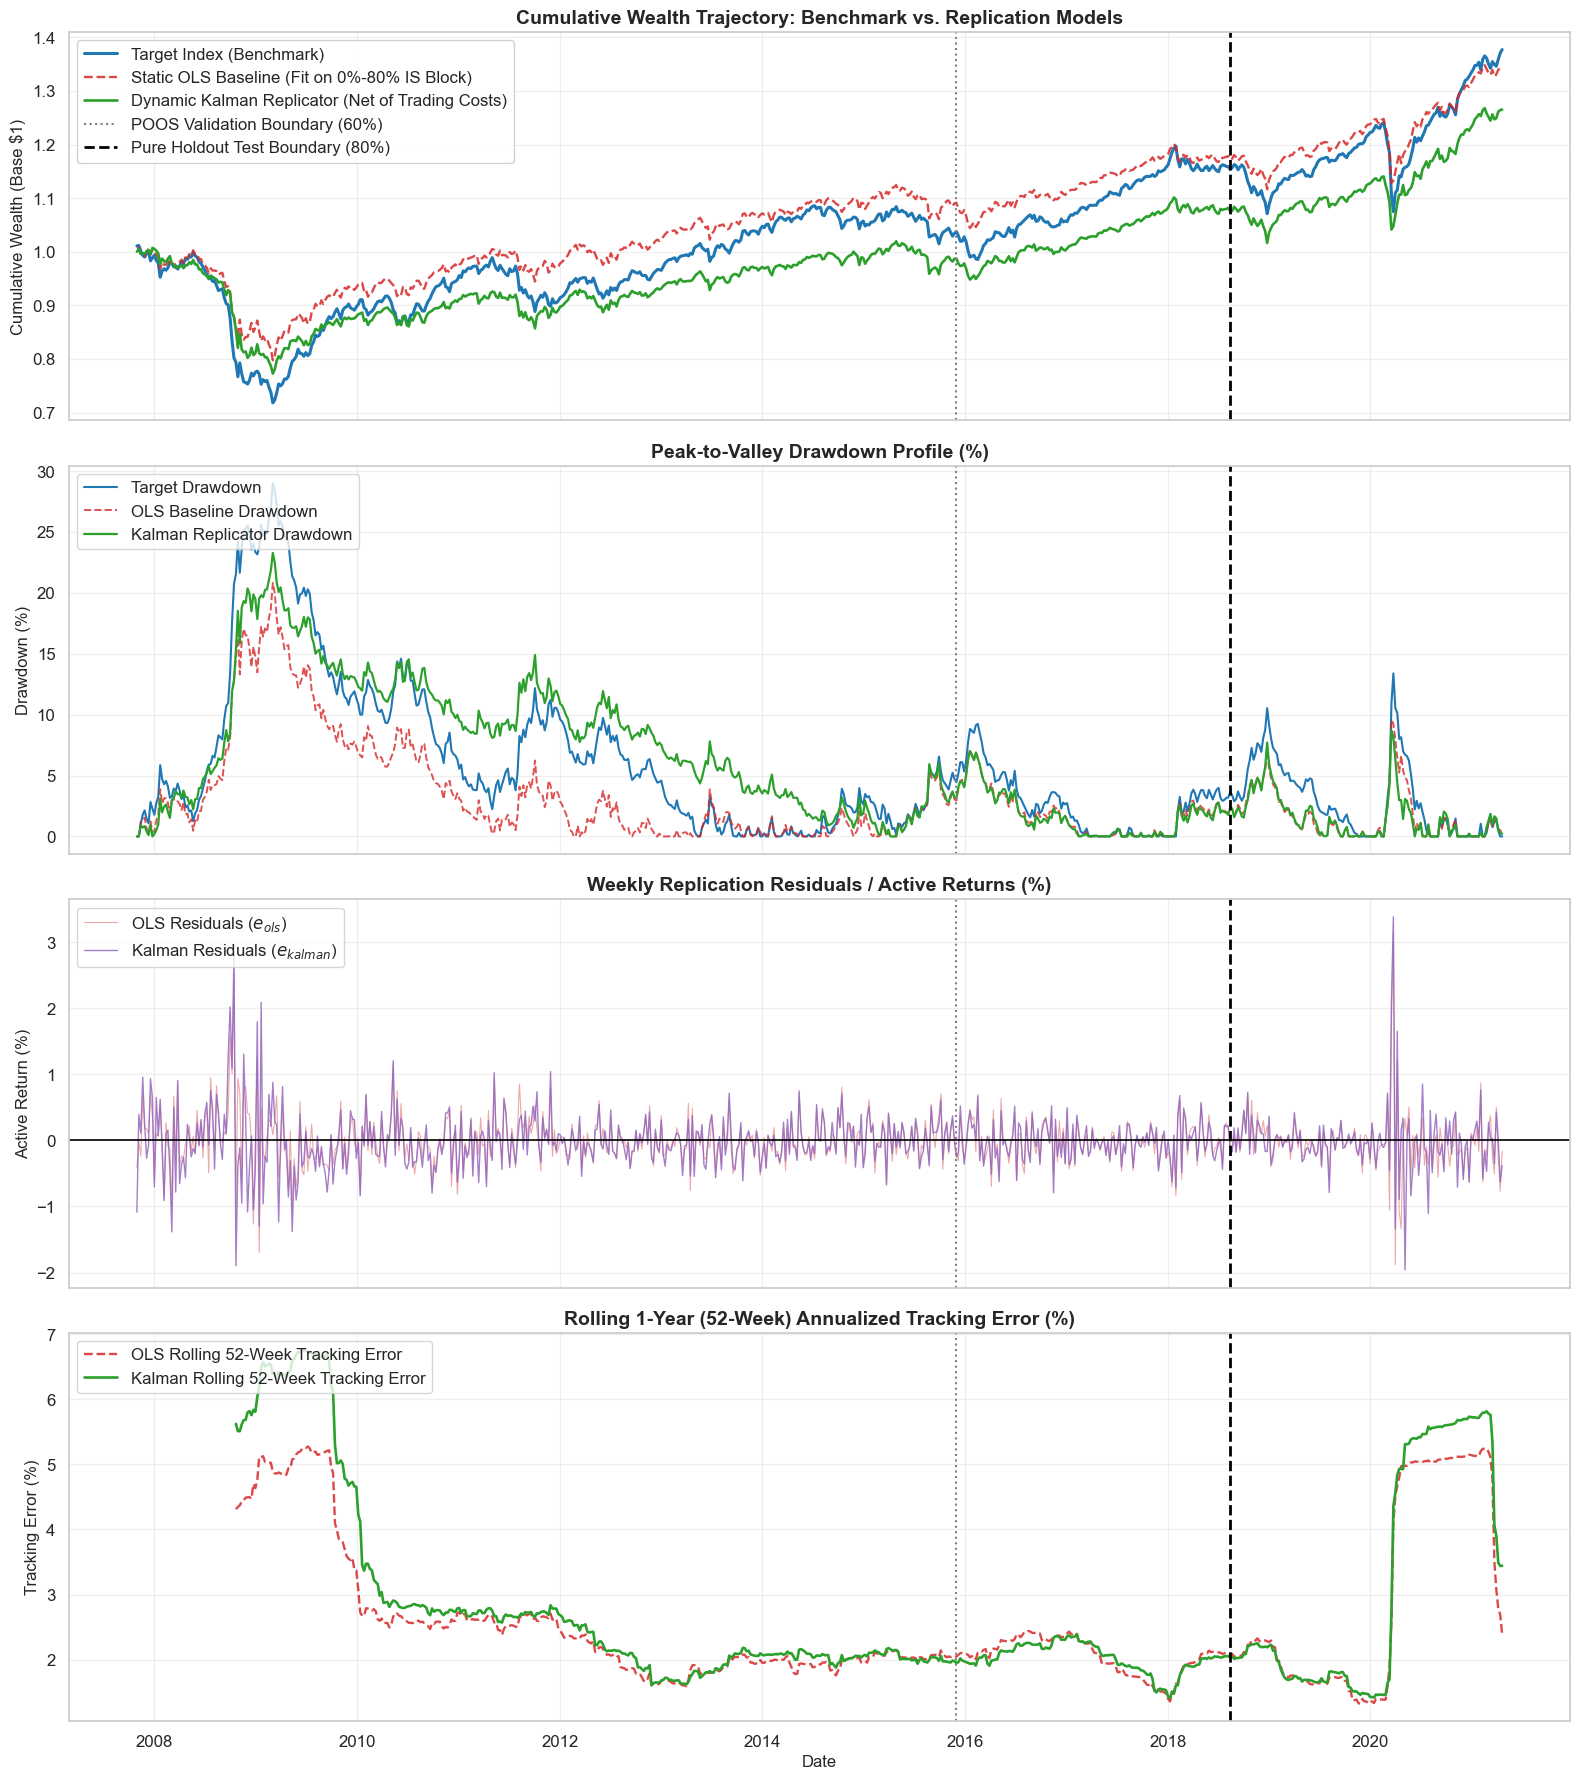

In [11]:
cum_target = (1.0 + Y_series).cumprod()
cum_ols = (1.0 + ols_ret_full).cumprod()
cum_kalman = (1.0 + kalman_ret_full).cumprod()

active_ret_ols = ols_ret_full - Y_series
active_ret_kalman = kalman_ret_full - Y_series

rolling_te_ols = active_ret_ols.rolling(window=52).std(ddof=1) * np.sqrt(52)
rolling_te_kalman = active_ret_kalman.rolling(window=52).std(ddof=1) * np.sqrt(52)

fig, axes = plt.subplots(4, 1, figsize=(16, 18), sharex=True)

# Panel 1: Cumulative Wealth Trajectory
axes[0].plot(
    cum_target.index,
    cum_target,
    label="Target Index (Benchmark)",
    color="#1f77b4",
    linewidth=2.2,
)
axes[0].plot(
    cum_ols.index,
    cum_ols,
    label="Static OLS Baseline (Fit on 0%-80% IS Block)",
    color="#d62728",
    linewidth=1.7,
    linestyle="--",
    alpha=0.85,
)
axes[0].plot(
    cum_kalman.index,
    cum_kalman,
    label="Dynamic Kalman Replicator (Net of Trading Costs)",
    color="#2ca02c",
    linewidth=1.9,
)
axes[0].axvline(
    Y_poos_val.index[0],
    color="gray",
    linestyle=":",
    linewidth=1.5,
    label="POOS Validation Boundary (60%)",
)
axes[0].axvline(
    Y_holdout_test.index[0],
    color="black",
    linestyle="--",
    linewidth=2.0,
    label="Pure Holdout Test Boundary (80%)",
)
axes[0].set_title(
    "Cumulative Wealth Trajectory: Benchmark vs. Replication Models",
    fontsize=14,
    fontweight="bold",
)
axes[0].set_ylabel("Cumulative Wealth (Base $1)", fontsize=12)
axes[0].legend(loc="upper left", frameon=True, facecolor="white", framealpha=0.9)
axes[0].grid(True, alpha=0.3)

# Panel 2: Peak-to-Valley Drawdown Profiles
dd_target = 1.0 - cum_target / cum_target.cummax()
dd_ols = 1.0 - cum_ols / cum_ols.cummax()
dd_kalman = 1.0 - cum_kalman / cum_kalman.cummax()

axes[1].plot(
    dd_target.index,
    dd_target * 100,
    label="Target Drawdown",
    color="#1f77b4",
    linewidth=1.5,
)
axes[1].plot(
    dd_ols.index,
    dd_ols * 100,
    label="OLS Baseline Drawdown",
    color="#d62728",
    linewidth=1.4,
    linestyle="--",
    alpha=0.8,
)
axes[1].plot(
    dd_kalman.index,
    dd_kalman * 100,
    label="Kalman Replicator Drawdown",
    color="#2ca02c",
    linewidth=1.6,
)
axes[1].axvline(Y_poos_val.index[0], color="gray", linestyle=":", linewidth=1.5)
axes[1].axvline(
    Y_holdout_test.index[0], color="black", linestyle="--", linewidth=2.0
)
axes[1].set_title(
    "Peak-to-Valley Drawdown Profile (%)", fontsize=14, fontweight="bold"
)
axes[1].set_ylabel("Drawdown (%)", fontsize=12)
axes[1].legend(loc="upper left", frameon=True, facecolor="white")
axes[1].grid(True, alpha=0.3)

# Panel 3: Weekly Active Returns (Replication Residuals e_t)
axes[2].plot(
    active_ret_ols.index,
    active_ret_ols * 100,
    color="#d62728",
    linewidth=0.8,
    alpha=0.4,
    label="OLS Residuals ($e_{ols}$)",
)
axes[2].plot(
    active_ret_kalman.index,
    active_ret_kalman * 100,
    color="#9467bd",
    linewidth=1.0,
    alpha=0.85,
    label="Kalman Residuals ($e_{kalman}$)",
)
axes[2].axhline(0, color="black", linestyle="-", linewidth=1.2)
axes[2].axvline(Y_poos_val.index[0], color="gray", linestyle=":", linewidth=1.5)
axes[2].axvline(
    Y_holdout_test.index[0], color="black", linestyle="--", linewidth=2.0
)
axes[2].set_title(
    "Weekly Replication Residuals / Active Returns (%)",
    fontsize=14,
    fontweight="bold",
)
axes[2].set_ylabel("Active Return (%)", fontsize=12)
axes[2].legend(loc="upper left", frameon=True, facecolor="white")
axes[2].grid(True, alpha=0.3)

# Panel 4: Rolling 1-Year (52-Week) Annualized Tracking Error
axes[3].plot(
    rolling_te_ols.index,
    rolling_te_ols * 100,
    color="#d62728",
    linewidth=1.7,
    linestyle="--",
    alpha=0.85,
    label="OLS Rolling 52-Week Tracking Error",
)
axes[3].plot(
    rolling_te_kalman.index,
    rolling_te_kalman * 100,
    color="#2ca02c",
    linewidth=1.9,
    label="Kalman Rolling 52-Week Tracking Error",
)
axes[3].axvline(Y_poos_val.index[0], color="gray", linestyle=":", linewidth=1.5)
axes[3].axvline(
    Y_holdout_test.index[0], color="black", linestyle="--", linewidth=2.0
)
axes[3].set_title(
    "Rolling 1-Year (52-Week) Annualized Tracking Error (%)",
    fontsize=14,
    fontweight="bold",
)
axes[3].set_xlabel("Date", fontsize=12)
axes[3].set_ylabel("Tracking Error (%)", fontsize=12)
axes[3].legend(loc="upper left", frameon=True, facecolor="white")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()